In [ ]:
# Execute first
import os
FIG_ROOT = os.environ.get('SCDIS_FIG', os.path.join(os.environ['SCDIS_ROOT'], 'figures'))

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import sem
from scipy.stats import wilcoxon

import os
import sys
sys.path.append('..')

import local_tools as lt

In [2]:
import matplotlib

matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Liberation Sans'
matplotlib.rcParams['mathtext.default'] = 'regular'
matplotlib.rcParams['axes.unicode_minus'] = False

In [3]:
save_path = f'{FIG_ROOT}/Prostate/cell_transition/ood_transition'
os.makedirs(save_path, exist_ok=True)

In [4]:
short_mapping = {
        'T02_Cast_Day7': 'C7',
        'T03_Cast_Day14': 'C14',
        'T04_Cast_Day28': 'C28',
        'T05_Regen_Day1': 'R1',
        'T06_Regen_Day2': 'R2',
        'T07_Regen_Day3': 'R3',
        'T08_Regen_Day7': 'R7',
        'T09_Regen_Day14': 'R14',
        'T10_Regen_Day28': 'R28'
    }

In [5]:
transition_mean_df = pd.read_csv("transition_mean_results.csv", index_col=0)
transition_mean_df['future_time'] = transition_mean_df['future_time'].map(short_mapping)

df_l2 = pd.read_csv('ood_per_l2_cell_outflow.csv')   # 97 cells × 9 transitions
df_l1 = pd.read_csv('ood_per_l1_cell_outflow.csv')    # 3211 × 9 transitions
cast_cols = [x for x in df_l1.columns.tolist() if not 'Regen' in x]
regen_cols = [x for x in df_l1.columns.tolist() if 'Regen' in x]

df_l2_cast_mean = df_l2[cast_cols].mean(axis=1)
df_l1_cast_mean = df_l1[cast_cols].mean(axis=1)

df_l2_regen_mean = df_l2[regen_cols].mean(axis=1)
df_l1_regen_mean = df_l1[regen_cols].mean(axis=1)

# Lineplot of transition probs across the C/R cycle

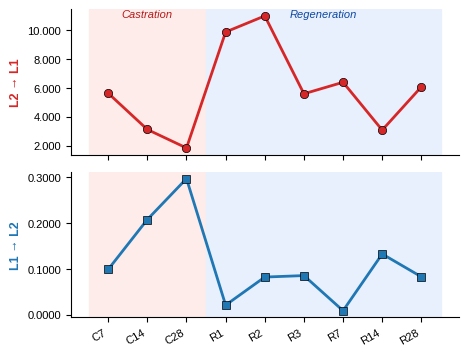

In [6]:
x = np.arange(len(transition_mean_df))
labels = transition_mean_df['future_time'].values
n_cast, n_total = 3, len(x)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 4), sharex=True,
                                gridspec_kw={'hspace': 0.12})

for ax in [ax1, ax2]:
   lt. phase_bg(ax, n_cast, n_total)

lt.nature_line(ax1, x, transition_mean_df['cell_l2_to_l1_mean'], '#D62728')
ax1.set_ylabel('L2 → L1', fontsize=9, color='#D62728', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
lt.phase_labels(ax1, n_cast, n_total)

lt.nature_line(ax2, x, transition_mean_df['cell_l1_to_l2_mean'], '#1F77B4', marker='s')
ax2.set_ylabel('L1 → L2', fontsize=9, color='#1F77B4', fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=8, rotation=30, ha='right')

plt.savefig(f'{save_path}/line_plot_combined.png', dpi=600)
plt.savefig(f'{save_path}/line_plot_combined.svg', dpi=600)

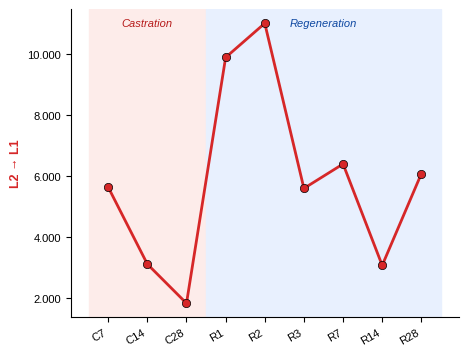

In [7]:
x = np.arange(len(transition_mean_df))
labels = transition_mean_df['future_time'].values
n_cast, n_total = 3, len(x)

fig, ax1 = plt.subplots(1, 1, figsize=(5, 4), sharex=True,
                                gridspec_kw={'hspace': 0.12})

lt.phase_bg(ax1, n_cast, n_total)

lt.nature_line(ax1, x, transition_mean_df['cell_l2_to_l1_mean'], '#D62728')
ax1.set_ylabel('L2 → L1', fontsize=9, color='#D62728', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
lt.phase_labels(ax1, n_cast, n_total)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=8, rotation=30, ha='right')

plt.savefig(f'{save_path}/line_plot_l2_to_l1.png', dpi=600)
plt.savefig(f'{save_path}/line_plot_l2_to_l1.svg', dpi=600)

# Average transition probs castration versus regeneration

In [8]:
avg_prob_transition_l2 = {
    'Regeneration': df_l2_regen_mean.mean(),
    'Castration': df_l2_cast_mean.mean(),
}

avg_prob_transition_l1 = {
    'Regeneration': df_l1_regen_mean.mean(),
    'Castration': df_l1_cast_mean.mean(),
}

colors = {
    'Regeneration': '#d62728',
    'Castration': '#00FFFF',
    }

# L2 to L1

(<Figure size 300x300 with 1 Axes>,
 <Axes: ylabel='Average Transition Probability'>)

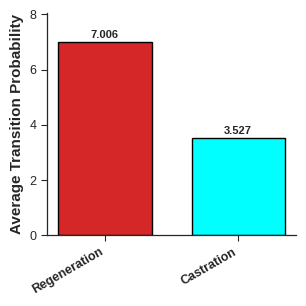

In [9]:
lt.plot_method_scores(
    avg_prob_transition_l2, 
    colors, 
    metric_label="Average Transition Probability",
    savepath=f'{save_path}/avg_l2_to_l1.svg', 
    dpi=600
)

In [10]:
df_l2_regen_mean.mean(), df_l2_cast_mean.mean()

(7.006491444553265, 3.526738194120275)

In [11]:
wilcoxon(df_l2_regen_mean, df_l2_cast_mean, alternative='greater')

WilcoxonResult(statistic=1035.0, pvalue=2.5896273886476888e-09)

# L1 to L2

(<Figure size 300x300 with 1 Axes>,
 <Axes: ylabel='Average Transition Probability'>)

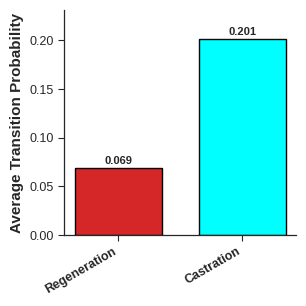

In [12]:
lt.plot_method_scores(
    avg_prob_transition_l1, 
    colors, 
    metric_label="Average Transition Probability",
    savepath=f'{save_path}/avg_l1_to_l2.svg', 
    dpi=600
)

In [13]:
df_l1_regen_mean.mean(), df_l1_cast_mean.mean()

(0.06855599228274993, 0.2011554867559431)

In [14]:
wilcoxon(df_l1_regen_mean, df_l1_cast_mean, alternative='less')

WilcoxonResult(statistic=2755.0, pvalue=0.09116993657935946)

# Plot by time-point

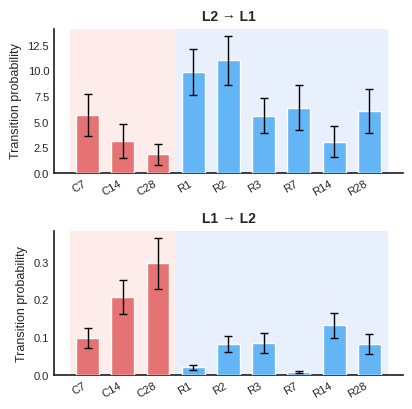

In [15]:
# short labels
short_labels = ['C7', 'C14', 'C28', 'R1', 'R2', 'R3', 'R7', 'R14', 'R28']
n_cast, n_regen = 3, 6  # first 3 = castration and last 6 regeneration

# statistics
l2_mean, l2_sem = df_l2.mean().values, df_l2.apply(sem).values
l1_mean, l1_sem = df_l1.mean().values, df_l1.apply(sem).values

# set colors
cast_color = '#E57373'
regen_color = '#64B5F6'
cast_bg, regen_bg = '#FDECEA', '#E8F0FE'

def style_barplot(ax, means, sems, title, ylabel):
    x = np.arange(len(short_labels))
    colors = [cast_color]*n_cast + [regen_color]*n_regen

    ax.axvspan(-0.5, n_cast - 0.5, color=cast_bg, zorder=0)
    ax.axvspan(n_cast - 0.5, len(x) - 0.5, color=regen_bg, zorder=0)

    ax.bar(x, means, yerr=sems, color=colors, edgecolor='white',
           width=0.65, capsize=3, error_kw={'lw': 1}, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, fontsize=8, rotation=30, ha='right')
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

# plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4.5, 4.5),
                                gridspec_kw={'hspace': 0.4})

style_barplot(ax1, l2_mean, l2_sem, 'L2 → L1', 'Transition probability')
style_barplot(ax2, l1_mean, l1_sem, 'L1 → L2', 'Transition probability')

plt.savefig(f'{save_path}/barplots_flow_variance.png', dpi=600)
plt.savefig(f'{save_path}/barplots_flow_variance.svg', dpi=600)